In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [3]:
x = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
x

array([[1],
       [2],
       [3],
       [4],
       [5]])

In [4]:
y = np.array([40, 50, 50, 60, 70])
y

array([40, 50, 50, 60, 70])

In [5]:
model = LinearRegression()
model.fit(x, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[7.]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,33
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[3.16]


In [6]:
print("Intercept : ", model.intercept_)
print("Slope : ", model.coef_[0])

Intercept :  33.0
Slope :  7.0


In [7]:
new_data = np.array([[6]])
predicted_mark = model.predict(new_data)

In [8]:
print("predicted mark : ", predicted_mark[0])

predicted mark :  75.0


In [9]:
y_pred = model.predict(x)
y_pred

array([40., 47., 54., 61., 68.])

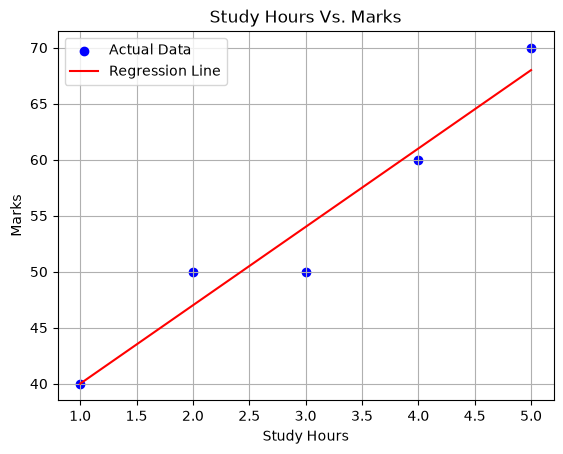

In [10]:
plt.scatter(x, y, color = "blue", label = "Actual Data")
plt.plot(x, y_pred, color = "red", label = "Regression Line")

plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Study Hours Vs. Marks")
plt.grid(True)
plt.legend()
plt.show()


In [11]:
from sklearn.metrics import(
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [12]:
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

In [13]:
print("Mean Absolute Error : ", mae)
print("Mean Squared Error : ", mse)
print("Root Mean Squared Error : ", rmse)
print("R-squared : ", r2)

Mean Absolute Error :  2.0
Mean Squared Error :  6.0
Root Mean Squared Error :  2.449489742783178
R-squared :  0.9423076923076923


After Applying Ridge :

In [14]:
from sklearn.linear_model import RidgeCV, Ridge, LassoCV, Lasso
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

model = make_pipeline(
    StandardScaler(),
    RidgeCV(alphas = [0.01, 0.1, 1, 10, 100])
)

model.fit(x, y)

ridge_model = model.named_steps["ridgecv"]
print("Best alpha : ", ridge_model.alpha_)

Best alpha :  0.01


In [15]:
model = make_pipeline(
    StandardScaler(),
    Ridge(alpha = 0.01)
    )

model.fit(x, y)
y_pred = model.predict(x)

In [16]:
ridge_step = model.named_steps['ridge']

print("Intercept : ", ridge_step.intercept_)
print("Standard coefficients : ", ridge_step.coef_)

Intercept :  54.0
Standard coefficients :  [9.87973547]


In [17]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

print("MAE       : ", mean_absolute_error(y, y_pred))
print("MSE       : ", mean_squared_error(y, y_pred))
print("RMSE      : ", np.sqrt(mean_squared_error(y, y_pred)))
print("R-squared : ", r2_score(y, y_pred))

MAE       :  2.00558882235529
MSE       :  6.000390436691488
RMSE      :  2.449569439042602
R-squared :  0.9423039381087357


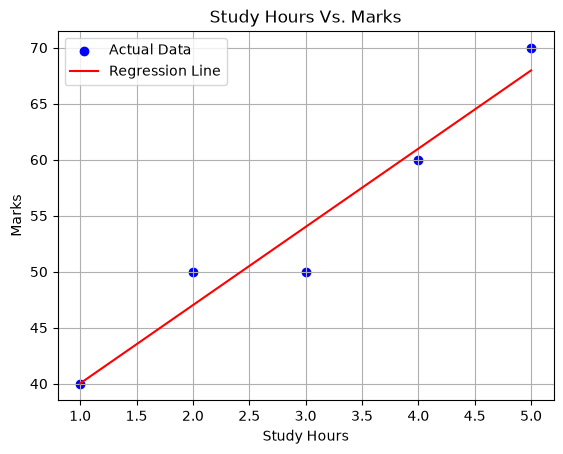

In [18]:
plt.scatter(x, y, color = "blue", label = "Actual Data")
plt.plot(x, y_pred, color = "red", label = "Regression Line")

plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Study Hours Vs. Marks")
plt.grid(True)
plt.legend()
plt.show()


Lasso Applied

In [19]:
model = make_pipeline(
    StandardScaler(),
    LassoCV(alphas = [0.01, 0.1, 1, 10, 100])
)

model.fit(x, y)

ridge_model = model.named_steps["lassocv"]
print("Best alpha : ", ridge_model.alpha_)

Best alpha :  0.01


In [20]:
model = make_pipeline(
    StandardScaler(),
    Lasso(alpha = 0.01)
    )

model.fit(x, y)
y_pred = model.predict(x)

In [21]:
lasso_step = model.named_steps['lasso']

print("Intercept : ", lasso_step.intercept_)
print("Standard coefficients : ", lasso_step.coef_)

Intercept :  54.0
Standard coefficients :  [9.88949494]


In [22]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

print("MAE       : ", mean_absolute_error(y, y_pred))
print("MSE       : ", mean_squared_error(y, y_pred))
print("RMSE      : ", np.sqrt(mean_squared_error(y, y_pred)))
print("R-squared : ", r2_score(y, y_pred))

MAE       :  2.002828427124746
MSE       :  6.000100000000001
RMSE      :  2.4495101551126504
R-squared :  0.9423067307692308


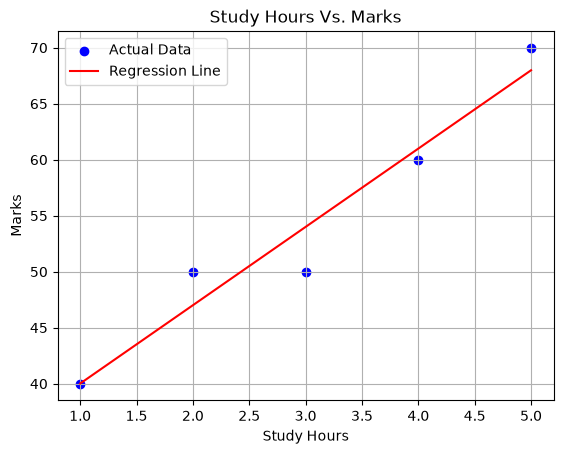

In [23]:
plt.scatter(x, y, color = "blue", label = "Actual Data")
plt.plot(x, y_pred, color = "red", label = "Regression Line")

plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Study Hours Vs. Marks")
plt.grid(True)
plt.legend()
plt.show()
